Code for only plotting saved results of autoencoder 
#### changelog 
+ v2- successfully runnig N iterations across all combinations
+ v3- adding WT CLNZ and streamlinecode. created N indepdenent bootstrap run code to evaluate staiblity of results. packaged resample function
+ cloud run plot results v1- added google colab local support  

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
%pip install -r autoencoder_cloud_requirements.txt
%matplotlib inline
import sys
import os
import logging #to suppress pytorch GPU output etc
import warnings
from pathlib import Path

#supress specific future warnings and automatic lighitning outputs
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.FATAL)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore",r".*does not have many workers which may be a bottleneck.*")
warnings.filterwarnings("ignore",".*GPU available.*",category=UserWarning) # option 2: just filter out the GPU‐warning
#run import modules for analysis 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
from tqdm import tqdm
import datetime
from sklearn.metrics import davies_bouldin_score
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},pandas ver: {pd.__version__}")
#torch imports
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from joblib import Parallel, delayed 
#custom loads
from external_functions import *
from sns_plotting_config import *
from ax_modifier_functions_cloud import *
plt.style.use('paper_plot.mplstyle') ## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

Note: you may need to restart the kernel to use updated packages.
matplotlib version: 3.7.0,sns version: 0.12.1,pandas ver: 1.5.2


In [ ]:
# Define the relative path to the src directory

root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
_plot_posthoc_src = os.path.join(root_dir, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

# Import functions and classes from plot_stat_annotate
from plot_posthoc_test.plot_stat_annotate import *



<Figure size 960x720 with 0 Axes>

In [ ]:
print(os.getcwd())

g:\My Drive\Colab Notebooks\lightning_autoencoder


## Process Data 


#### Create dataset object for resampling in bootstrapabs

In [ ]:
folder_loc = '/Run Outputs/'
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
print(f"date tag: {date_tag}")
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + "/"

date tag: 01_Jan_2026


In [ ]:
# new folder structure:
# outputs/                     # For trained models and results
# │   ├── models/                  # Trained model checkpoints
# │   ├── figures/                 # Generated figures
# │   └── logs/                    # Lightning logs
    
data_folder = os.getcwd() +"/data/"
output_folder = os.getcwd() +"/output/"
model_results_folder = output_folder + "/model_results/"
current_run_output = model_results_folder + f"{date_tag}\\"
all_figure_output_folder = output_folder +"/figures/"
fig_output = all_figure_output_folder + f"{date_tag}\\"
#make folders 
make_folder(output_folder)
make_folder(all_figure_output_folder)
make_folder(fig_output)
make_folder(model_results_folder)
make_folder(current_run_output)

'g:\\My Drive\\Colab Notebooks\\lightning_autoencoder/output//model_results/01_Jan_2026\\'

In [ ]:
#declare loc/names of files to read
load_dataset = True
save_norm_trial_dataset = True
trial_df_filename =  data_folder +  r"python-made_trial_timeseries_raster_2025-12-21 12.parquet"
# timeseries_loc +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"

if load_dataset:
    print(f"loading_dataset")
    trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
else:
    trial_tseries_df_norm = get_normed_trial_tseries(enriched_by_stage_path,post_activity_timeseries, hyper_param_dict) #OPTIONAL- drop  timebins #drop N bins if applicable
    if save_norm_trial_dataset:
        print(f"saving {trial_df_filename}")
        trial_tseries_df_norm.to_parquet(trial_df_filename)
trial_tseries_df_norm.tail()

loading_dataset


,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_RS_Correct,Late_RS,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial,normalization,data_type,date saved
3947,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-95,3,...,0.0,0.0,1.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3948,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3949,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-97,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3950,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3951,38,cell_99,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-99,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12


In [ ]:
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") #in external_functions.py
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = 'neuron_id', subj_name_col = 'subject_name')#.rename({'neuron_id': "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
subject_stage_info_df.tail()

geno_day
Het CLNZ         840
Het VEH          851
Het postCLNZ     914
WT CLNZ          985
WT VEH          1034
Name: neuron_id, dtype: int64
4624


,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23,171,"[3, 5]",2,"[False, False]"
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10,171,"[17, 19, 21]",3,"[True, True, True]"
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12,171,"[18, 20]",2,"[True, True]"
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16,171,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4,171,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### Retrieve cloud generated Bootstrap over all combinations 

In [ ]:
os.getcwd()

'g:\\My Drive\\Colab Notebooks\\lightning_autoencoder'

In [ ]:
last_bootstrap_run = data_folder + "NN 10000 bootstrap_DB_index_results_01_Jan_2026.parquet" #
# "//data//NN 1000 bootstrap_ DB index results_24_Jun_2025.parquet"
load_last_bootstrap_output = True
#set parameters 
ens_stage_pairs_subset = {'Early_IA_Correct_v_Early_RS_Correct':['Early_IA_Correct', 'Early_RS_Correct'],
                              'Early_IA_Error_v_Early_RS_Error':['Early_IA_Error', 'Early_RS_Error'],
                              'Late_IA_v_Early_RS_Correct':['Late_IA', 'Early_RS_Correct'],
                              'Early_IA_Correct_v_Late_IA':['Early_IA_Correct','Late_IA'] }
geno_plot = geno_order_w_WT_CLNZ
    
bootstrap_output =pd.read_parquet(last_bootstrap_run)
#regardless of choice for acquiring df, print info
print(bootstrap_output.info())
bootstrap_output.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 415000 entries, 0 to 249
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model_run     415000 non-null  int64  
 1   DB_index      415000 non-null  float64
 2   n_epochs      415000 non-null  int64  
 3   final_loss    415000 non-null  float64
 4   ensemble      415000 non-null  object 
 5   geno_day      415000 non-null  object 
 6   comparison    415000 non-null  object 
 7   lossDelta     415000 non-null  float64
 8   class_1_mean  415000 non-null  float64
 9   class_2_mean  415000 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 34.8+ MB
None


,model_run,DB_index,n_epochs,final_loss,ensemble,geno_day,comparison,lossDelta,class_1_mean,class_2_mean
0,0,0.719025,50,0.03726,Early_IA_Correct,WT VEH,Early_IA_Correct_v_Early_RS_Correct,0.0458,0.0761,0.0304
1,1,0.693106,50,0.03726,Early_IA_Correct,WT VEH,Early_IA_Correct_v_Early_RS_Correct,0.0458,0.0753,0.0307
2,2,0.636072,50,0.03726,Early_IA_Correct,WT VEH,Early_IA_Correct_v_Early_RS_Correct,0.0458,0.0772,0.0307
3,3,0.730562,50,0.03726,Early_IA_Correct,WT VEH,Early_IA_Correct_v_Early_RS_Correct,0.0458,0.0755,0.0323
4,4,0.850938,50,0.03726,Early_IA_Correct,WT VEH,Early_IA_Correct_v_Early_RS_Correct,0.0458,0.0738,0.0299


In [ ]:
bootstrap_output.model_run.max()

9999

[None, None]

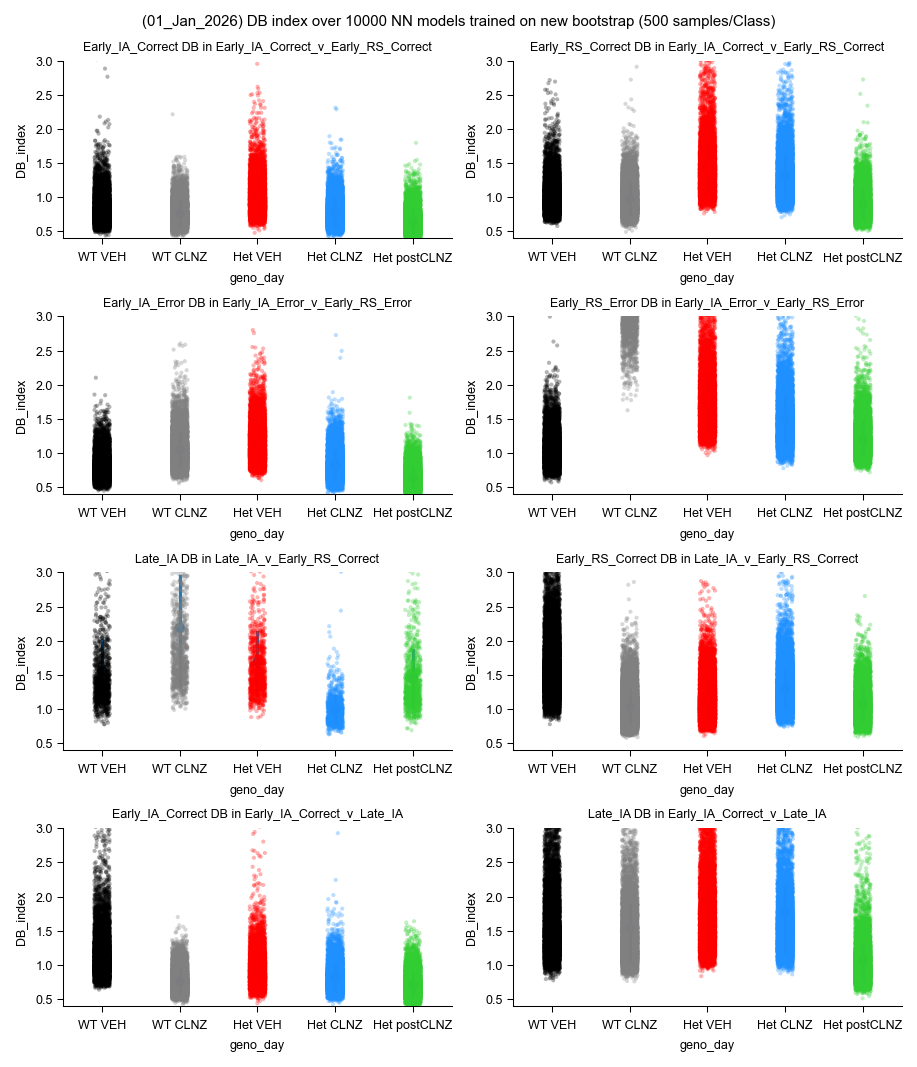

In [ ]:
end_val = bootstrap_output.model_run.max()+1
#plot N NN runs
fig,ax_array = plt.subplots(len(ens_stage_pairs_subset.keys()),2, figsize = (6,7), layout = 'constrained')
for c, comparison in enumerate(ens_stage_pairs_subset.keys()):
    for e, ens in enumerate(ens_stage_pairs_subset[comparison]):
        ax = ax_array[c,e]
        facet_mask = (bootstrap_output.comparison == comparison) & (bootstrap_output.ensemble ==ens)
        plot_db = bootstrap_output.loc[facet_mask, :]
        sns.pointplot(ax = ax, data = plot_db, x = 'geno_day',  y = 'DB_index', order = geno_order_w_WT_CLNZ, linestyles = 'None', dodge = False,errorbar = ('pi', 75))#showcaps=False,fliersize = 0)
        sns.stripplot(ax = ax, data =plot_db, x = 'geno_day', y = 'DB_index', **geno_order_w_WT_CLNZ_no_eb, alpha = 0.3, s = 2,dodge = False)#showcaps=False,fliersize = 0)
        set_labels(ax, label_dict = {'legend_false':True, 'ylim': [0.4, 3], 'title': f"{ens} DB in {comparison}"})
    
##save fig
fig.suptitle(f"({date_tag}) DB index over {end_val} NN models trained on new bootstrap (500 samples/Class)")
fig_name =f"{end_val} NN boostrap-  DB index _{date_tag}"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

#### Create Latent Space Viz- 1 autoencoder per comparison x ensembles

In [ ]:
run_autoencoder=False
save_model = True

In [ ]:
autoencoder_record = 'last_autoencoder_run_info.txt'
autoencoder_run_versions = f"autoencoder project- run version record_01_Jan_2026.csv"
autoencoder_embed_name = data_folder + "/Autoencoder_latent_space_01_Jan_2026_500Sample.parquet"
resample_type_str = {True: f"_Embed Train Data", False: f"_Embed New Data"}
#save files based on conditions
# run_record= pd.read_csv(data_folder+ autoencoder_run_versions)
# f = open(autoencoder_record, "r")
# autoencode_run_txt = f.read()
# autoencode_filename = autoencode_run_txt.split(': ')[1].split('. Run')[0]
# print(autoencode_filename)
embed_record =pd.read_parquet(autoencoder_embed_name)
# print(run_record.iloc[-5:,:])
embed_record

,embed_1,embed_2,labels,classes_decoded,geno_day,ensemble,class_0,class_1,n_frames,num_epochs,mean_loss,n_cells,dropout,test_on_train,date_run
0,-0.243780,0.356814,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
1,-0.158054,0.275016,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
2,-0.491235,0.041249,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
3,-0.023908,0.315963,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
4,-0.277700,-0.010344,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,117,50,0.037174,117,0.05,False,01_Jan_2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.240630,0.127423,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
496,0.363714,0.242976,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
497,0.299756,0.000479,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026
498,0.230927,0.069141,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,112,50,0.037174,112,0.05,False,01_Jan_2026


## Bootstrap density score- embedded

In [ ]:
run_latent_embedding_sample= False

ensemble_plot = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error']
geno_plot =  geno_order
decode_plot = ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error']
run_info_list = []

#### Run bootstrap projections and/or load previous bootstrap projections

In [ ]:
def set_bootstrap_index_every_N_rows(input_df:pd.DataFrame = pd.DataFrame(),
                                     input_filter= ['classes_decoded','ensemble','geno_day'],
                                     n_class_samples:int = 400, 
                                     bootstrap_col_name:str = 'strap'):
    ''' To get every N rows (default N = 400) and assign to a bootstrap index'''
    grouped_df = []
    for group_key, group_df in input_df.groupby(by = input_filter):
        grouped_df.append(group_df.assign(
            **{bootstrap_col_name: group_df.reset_index().index.values//n_class_samples}))
    grouped_df = pd.concat(grouped_df)
    return grouped_df

def balance_labels_of_bootstrap(df:pd.DataFrame, labels:list = [0,1], **kwargs):
    '''' to get label 1 df and label 2 df, recombine then export'''
    ##get labels == 0 df, then labels == 1
    df_1 = df[df['labels'] == labels[0]]
    df_2 = df[df['labels'] == labels[1]]
    # add bootstrap index
    group_df_1 = set_bootstrap_index_every_N_rows(df_1, **kwargs)
    group_df_2 =set_bootstrap_index_every_N_rows(df_2, **kwargs)
    #recombine into bootstrap projections df
    balanced_df = pd.concat([group_df_1,group_df_2], ignore_index=True)
    return balanced_df

#### Check spread by bootstrap iteration

In [ ]:
mean_density = bootstrap_output.set_index(['comparison', 'ensemble'])
mean_density

model_run  DB_index  \
comparison                          ensemble                                
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct          0  0.719025   
                                    Early_IA_Correct          1  0.693106   
                                    Early_IA_Correct          2  0.636072   
                                    Early_IA_Correct          3  0.730562   
                                    Early_IA_Correct          4  0.850938   
...                                                         ...       ...   
Late_IA_v_Early_RS_Correct          Late_IA                 995  2.587606   
                                    Late_IA                 996  1.042605   
                                    Late_IA                 997  1.275586   
                                    Late_IA                 998  1.744592   
                                    Late_IA                 999  1.622794   

                                                      n_epochs  final_loss  \
comparison                          ensemble                                 
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
                                    Early_IA_Correct        50    0.037260   
...                                                        ...         ...   
Late_IA_v_Early_RS_Correct          Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   
                                    Late_IA                 50    0.037542   

                                                          geno_day  lossDelta  \
comparison                          ensemble                                    
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
                                    Early_IA_Correct        WT VEH     0.0458   
...                                                            ...        ...   
Late_IA_v_Early_RS_Correct          Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   
                                    Late_IA           Het postCLNZ     0.0607   

                                                      class_1_mean  \
comparison                          ensemble                         
Early_IA_Correct_v_Early_RS_Correct Early_IA_Correct        0.0761   
                                    Early_IA_Correct        0.0753   
                                    Early_IA_Correct        0.0772   
                                    Early_IA_Correct        0.0755   
                                    Early_IA_Correct        0.0738   
...                                                            ...   
Late_IA_v_Early_RS_Correct          Late_IA                 0.1083   
                                    Late_IA                 0.1068   
                                    Late_IA                 0.1091   
                                    Late_IA                 0.1047   
                                    Late_IA                 0.1065   

                                                      class_2_mean  
com

#### Plot density score per bootstrap

In [ ]:
unique_comparisons = list(set(mean_density.index.get_level_values('comparison')))
unique_comparisons

['Early_IA_Correct_v_Early_RS_Correct',
 'Late_IA_v_Early_RS_Correct',
 'Early_IA_Error_v_Early_RS_Error',
 'Early_IA_Correct_v_Late_IA']

In [ ]:
score_df = mean_density
score_type = 'Davies-Bouldin index'
comparison =unique_comparisons[0]
comparison_df =score_df.loc[comparison,:]
ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
print(ensemble_subset)
comparison_df


['Early_IA_Correct', 'Early_RS_Correct']


,model_run,DB_index,n_epochs,final_loss,geno_day,lossDelta,class_1_mean,class_2_mean
ensemble,,,,,,,,
Early_IA_Correct,0,0.719025,50,0.037260,WT VEH,0.0458,0.0761,0.0304
Early_IA_Correct,1,0.693106,50,0.037260,WT VEH,0.0458,0.0753,0.0307
Early_IA_Correct,2,0.636072,50,0.037260,WT VEH,0.0458,0.0772,0.0307
Early_IA_Correct,3,0.730562,50,0.037260,WT VEH,0.0458,0.0755,0.0323
Early_IA_Correct,4,0.850938,50,0.037260,WT VEH,0.0458,0.0738,0.0299
...,...,...,...,...,...,...,...,...
Early_RS_Correct,995,0.907560,50,0.037542,Het postCLNZ,0.0607,0.0640,0.1373
Early_RS_Correct,996,0.802450,50,0.037542,Het postCLNZ,0.0607,0.0642,0.1342
Early_RS_Correct,997,0.671963,50,0.037542,Het postCLNZ,0.0607,0.0633,0.1376


In [ ]:
print(unique_comparisons)
mean_density.reset_index().comparison.nunique()

['Early_IA_Correct_v_Early_RS_Correct', 'Late_IA_v_Early_RS_Correct', 'Early_IA_Error_v_Early_RS_Error', 'Early_IA_Correct_v_Late_IA']


4

{'pooled_sd': 0.10217133517330014, 'group_mean_diff': 0.06048984780915301, 'group_1_mean': 0.8099630453231832, 'group_1_std': 0.1090651555741027, 'group_2_mean': 0.7494731975140302, 'group_2_std': 0.09477739868653524, 'cohen_d': 0.5920432350869432, 'pseudo_pvalue': 0.2769108185310907, 'permutation_test_pvalue': 9.999000099990002e-05}
{'pooled_sd': 0.11933653541834394, 'group_mean_diff': 0.16148648320381953, 'group_1_mean': 0.8099630453231832, 'group_1_std': 0.1090651555741027, 'group_2_mean': 0.9714495285270027, 'group_2_std': 0.1287913398132968, 'cohen_d': 1.353202375431091, 'pseudo_pvalue': 0.08799549330321266, 'permutation_test_pvalue': 9.999000099990002e-05}
{'pooled_sd': 0.11687682592254321, 'group_mean_diff': 0.21722058434284786, 'group_1_mean': 0.9714495285270027, 'group_1_std': 0.1287913398132968, 'group_2_mean': 0.7542289441841549, 'group_2_std': 0.10360104084686048, 'cohen_d': 1.8585428088781655, 'pseudo_pvalue': 0.03154598503962647, 'permutation_test_pvalue': 9.9990000999900

[None, None]

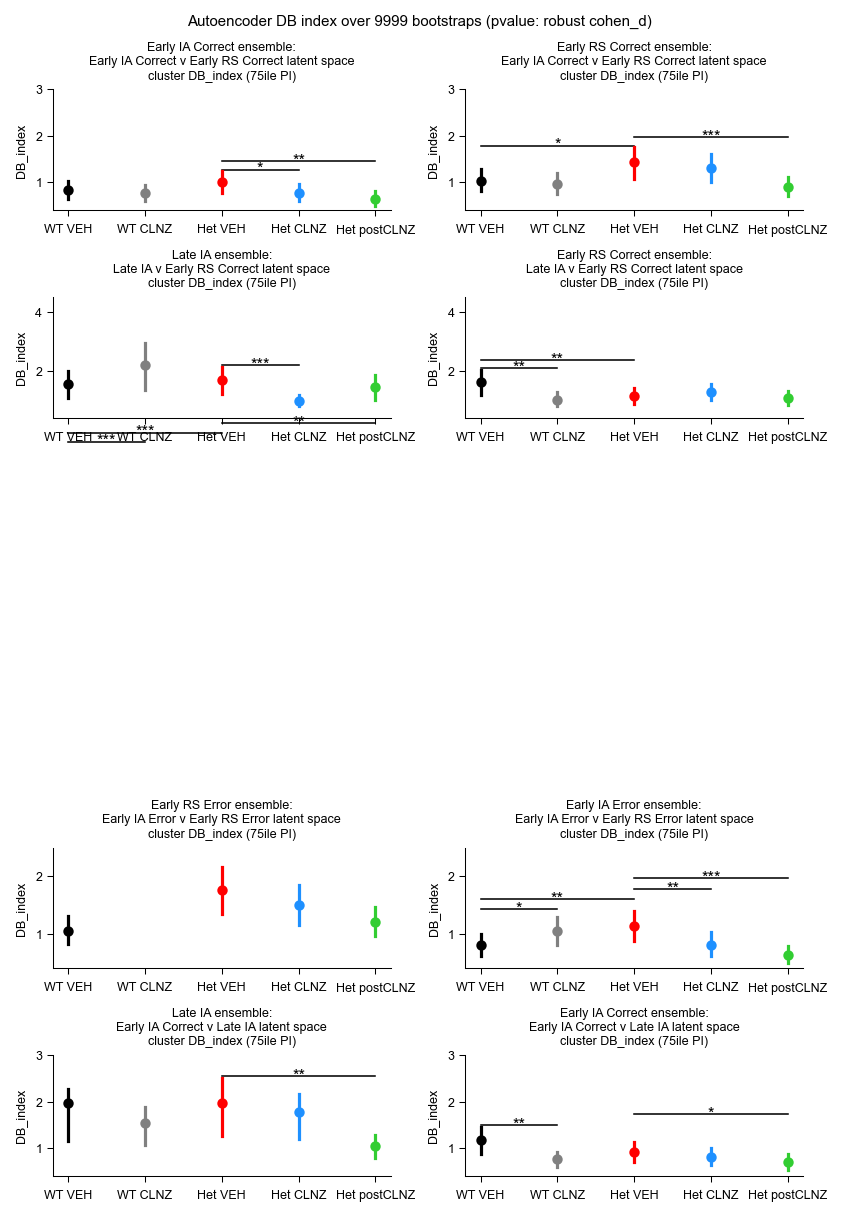

In [ ]:

fig_dims = dict(ncols=2,nrows =len(unique_comparisons))
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.75*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
score_df = mean_density
score_type = 'DB_index'
# score_type = 'Davies-Bouldin index'
posthoc_list = []
ylim_list = [[0.4,3],
             [0.4,4.5],
             [0.4,2.5],
            [0.4,3]]
stat_test = 'cohen_d'
#iterate over comparisons
for c, comparison in enumerate(unique_comparisons):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"
        set_labels(ax =plot_ax, label_dict = {'title': ax_title, 'legend_false': True , 'xlabel': None,'ylim': ylim_list[c]})
        
        ## plot stat annotate
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc,
                                                               comparison_list_w_WT_CLNZ, 
                                                               test_name = stat_test,
                                                               ax_var_is_hue=True,detect_error_bar = True)
        plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.015,offset_constant=0.015) 
        comparison_name=f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space"
        
        posthoc_list.append(posthoc_df.assign(comparison=   comparison_name))
        
posthoc_df = pd.concat(posthoc_list)
##save fig & CSV
n_shuffles = score_df.model_run.max()
fig_name = f"Autoencoder-DB index {n_shuffles} bootstrap (pvalue- {stat_test}) "
fig.suptitle(f"Autoencoder DB index over {n_shuffles} bootstraps (pvalue: robust {stat_test}) ")
#save posthoc CSV
# save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4",fig_name,csv_folder_most_recent, csv_folder_current_run,                            csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

[None, None]

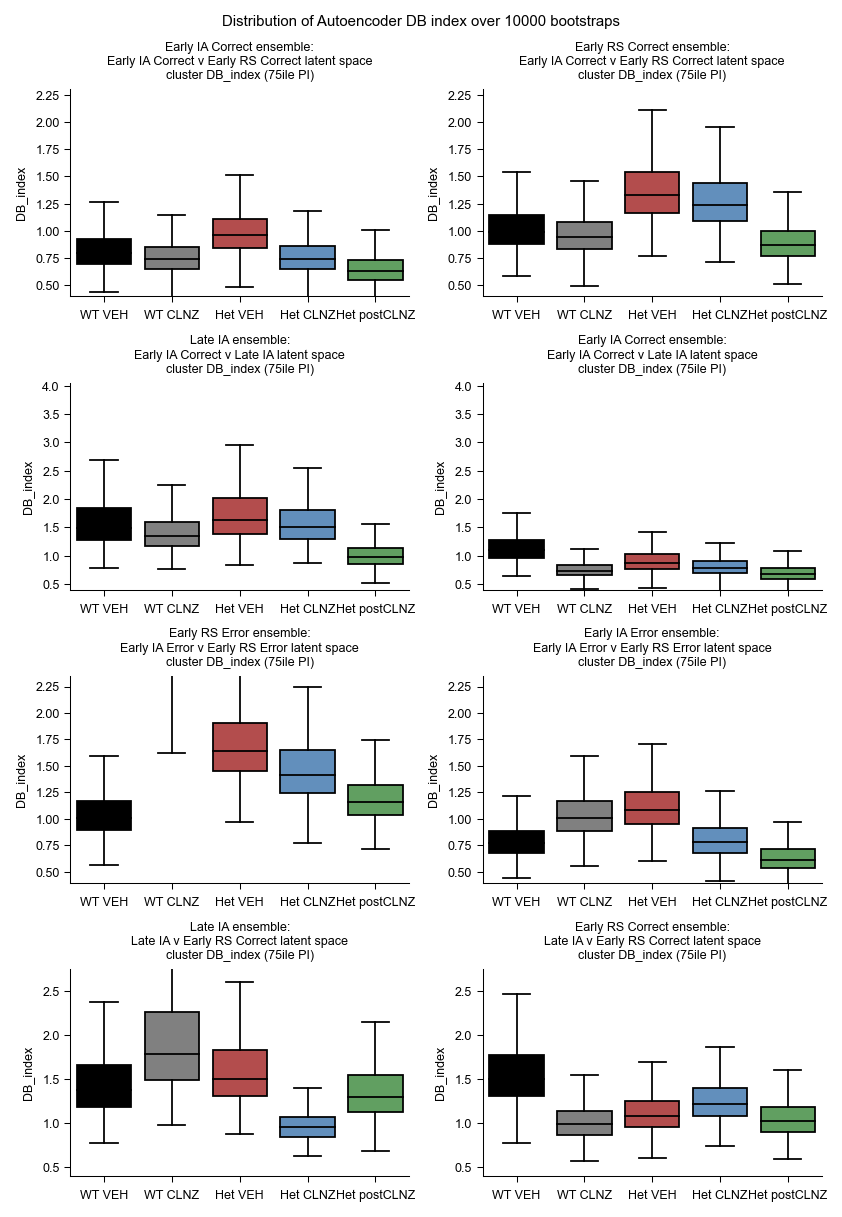

In [ ]:

fig_dims = dict(ncols=2,nrows = mean_density.reset_index().comparison.nunique())
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.75*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
score_df = mean_density
score_type = 'DB_index'

# score_type = 'Davies-Bouldin index'
posthoc_list = []
ylim_list = [[0.4,2.3],
             [0.4,4.05],
             [0.4,2.35],
            [0.4,2.75]]
#iterate over comparisons
for c, comparison in enumerate(mean_density.reset_index().comparison.unique()):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.boxplot(ax =plot_ax, fliersize =0,dodge = False,saturation = 0.4, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"
        
        # ## plot stat annotate
        # posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc,
        #                                                        comparison_list_w_WT_CLNZ, 
        #                                                        test_name = 'permutation_test',ax_var_is_hue=True,detect_error_bar = True)
        # plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.02,offset_constant=0.015) 
        comparison_name=f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space"
        set_labels(ax =plot_ax, label_dict = {'title': ax_title, 'legend_false': True , 'xlabel': None,'ylim': ylim_list[c]})
        # posthoc_list.append(posthoc_df.assign(comparison=   comparison_name))

fig_name = f"Distribution of Autoencoder DB index over {end_val} bootstraps"
fig.suptitle(fig_name)

#save posthoc CSV
# save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4",fig_name,csv_folder_most_recent, csv_folder_current_run,
#                                 csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

In [ ]:
cols_to_drop = ['y_is_nonnan', 'y_is_2_elem',
                'g_1_child_x','g_1_child_y',
                'g_2_child_x','g_2_child_y',
                'g1_num_loc','g2_num_loc',
                'g1_cat_loc','g2_cat_loc',
                'hue_group_1_locs','hue_group_2_locs',
                'group_1_order_pos', 'group_2_order_pos',
                'group_1_order_pos', 'group_2_order_pos']
all_posthoc = posthoc_df.drop(cols_to_drop, axis = 1)
all_posthoc.to_csv(f"DB index mean diff {stat_test} posthoc test.csv")
all_posthoc

,category_compared_within,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_sem,group_2_mean,group_2_sem,test_name,stat_result,pvalue,categorical_subgroup,max_group_loc_val,numeric_var,hue_var,x_category_var,hue_is_x_axis,comparison
0,geno_day,WT VEH,WT CLNZ,"(11000,)","(11000,)",0.8100,0.1091,0.7495,0.0948,robust_cohen_d,"[0.59204, 0.27691, 0.0001]",0.276911,"(WT VEH, WT CLNZ)",1.036429,DB_index,geno_day,geno_day,True,Early IA Correct ensemble:\nEarly IA Correct v...
1,geno_day,WT VEH,Het VEH,"(11000,)","(11000,)",0.8100,0.1091,0.9714,0.1288,robust_cohen_d,"[1.3532, 0.088, 0.0001]",0.087995,"(WT VEH, Het VEH)",1.239560,DB_index,geno_day,geno_day,True,Early IA Correct ensemble:\nEarly IA Correct v...
2,geno_day,Het VEH,Het CLNZ,"(11000,)","(11000,)",0.9714,0.1288,0.7542,0.1036,robust_cohen_d,"[1.85854, 0.03155, 0.0001]",0.031546,"(Het VEH, Het CLNZ)",1.239560,DB_index,geno_day,geno_day,True,Early IA Correct ensemble:\nEarly IA Correct v...
3,geno_day,Het VEH,Het postCLNZ,"(11000,)","(11000,)",0.9714,0.1288,0.6378,0.0882,robust_cohen_d,"[3.0227, 0.00125, 0.0001]",0.001253,"(Het VEH, Het postCLNZ)",1.239560,DB_index,geno_day,geno_day,True,Early IA Correct ensemble:\nEarly IA Correct v...
0,geno_day,WT VEH,WT CLNZ,"(11000,)","(11000,)",1.0099,0.1275,0.9530,0.1206,robust_cohen_d,"[0.45842, 0.32333, 0.0001]",0.323327,"(WT VEH, WT CLNZ)",1.280592,DB_index,geno_day,geno_day,True,Early RS Correct ensemble:\nEarly IA Correct v...
1,geno_day,WT VEH,Het VEH,"(11000,)","(11000,)",1.0099,0.1275,1.3504,0.1817,robust_cohen_d,"[2.16968, 0.01502, 0.0001]",0.015016,"(WT VEH, Het VEH)",1.755814,DB_index,geno_day,geno_day,True,Early RS Correct ensemble:\nEarly IA Correct v...
2,geno_day,Het VEH,Het CLNZ,"(11000,)","(11000,)",1.3504,0.1817,1.2635,0.1661,robust_cohen_d,"[0.49942, 0.30874, 0.0001]",0.308743,"(Het VEH, Het CLNZ)",1.755814,DB_index,geno_day,geno_day,True,Early RS Correct ensemble:\nEarly IA Correct v...
3,geno_day,Het VEH,Het postCLNZ,"(11000,)","(11000,)",1.3504,0.1817,0.8815,0.1131,robust_cohen_d,"[3.09846, 0.00097, 0.0001]",0.000973,"(Het VEH, Het postCLNZ)",1.755814,DB_index,geno_day,geno_day,True,Early RS Correct ensemble:\nEarly IA Correct v...
0,geno_day,WT VEH,WT CLNZ,"(1000,)","(1000,)",1.4181,0.2370,1.8776,0.3870,robust_cohen_d,"[1.43182, 0.0761, 0.0001]",0.076097,"(WT VEH, WT CLNZ)",2.940577,DB_index,geno_day,geno_day,True,Late IA ensemble:\nLate IA v Early RS Correct ...
1,geno_day,WT VEH,Het VEH,"(1000,)","(1000,)",1.4181,0.2370,1.5570,0.2451,robust_cohen_d,"[0.57639, 0.28218, 0.0001]",0.282175,"(WT VEH, Het VEH)",2.121189,DB_index,geno_day,geno_day,True,Late IA ensemble:\nLate IA v Early RS Correct ...


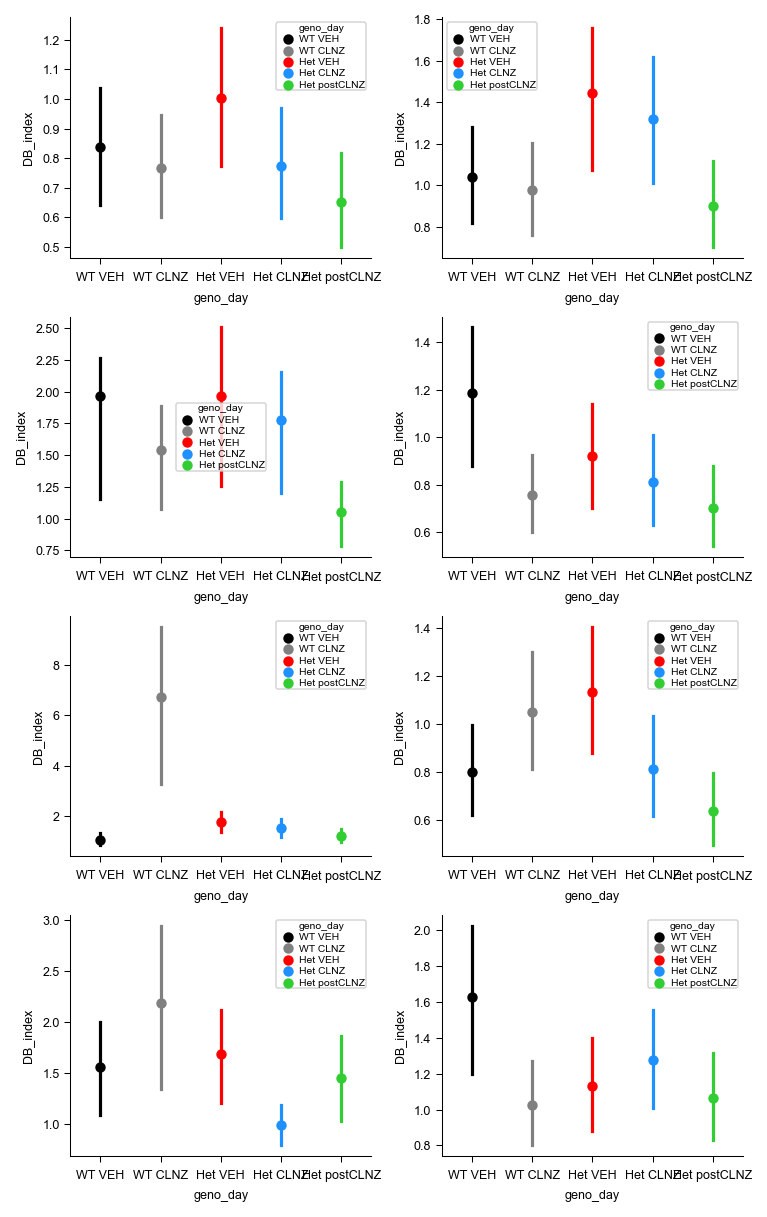

In [ ]:

fig_dims = dict(ncols=2,nrows = mean_density.reset_index().comparison.nunique())
fig,ax_array = plt.subplots(**fig_dims, figsize = (2.5*fig_dims['ncols'], 2*fig_dims['nrows']), sharey= False,
                             layout = 'constrained')
#iterate over comparisons
for c, comparison in enumerate(mean_density.reset_index().comparison.unique()):
    comparison_df =score_df.loc[comparison,:]
    ensemble_subset = list(set(comparison_df.index.get_level_values('ensemble')))
    for e,ensemble in enumerate(ensemble_subset): #iterate over ensembles
        plot_score =comparison_df.loc[ensemble,:]
        
        plot_ax = ax_array[c,e]
        plot_params = dict(data = plot_score, x = 'geno_day', y =score_type,
                           order = geno_order_w_WT_CLNZ, **format_no_eb_w_WT_CLNZ,)# palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params)
        # plot_ax.get_legend().remove()    
        ax_title = f"{ensemble.replace("_", " ")} ensemble:\n{comparison.replace("_", " ")} latent space\ncluster {score_type} (75ile PI)"

In [ ]:
comparison_df

,model_run,DB_index,n_epochs,final_loss,geno_day,lossDelta,class_1_mean,class_2_mean
ensemble,,,,,,,,
Early_RS_Correct,0,1.098547,50,0.037004,WT VEH,0.0609,0.0455,0.0899
Early_RS_Correct,1,0.889131,50,0.037004,WT VEH,0.0609,0.0460,0.0925
Early_RS_Correct,2,1.533867,50,0.037004,WT VEH,0.0609,0.0469,0.0899
Early_RS_Correct,3,1.686780,50,0.037004,WT VEH,0.0609,0.0451,0.0923
Early_RS_Correct,4,1.574533,50,0.037004,WT VEH,0.0609,0.0469,0.0901
...,...,...,...,...,...,...,...,...
Late_IA,995,2.587606,50,0.037542,Het postCLNZ,0.0607,0.1083,0.0653
Late_IA,996,1.042605,50,0.037542,Het postCLNZ,0.0607,0.1068,0.0651
Late_IA,997,1.275586,50,0.037542,Het postCLNZ,0.0607,0.1091,0.0664


###  Figure- Cluster density in latent space subsets

In [ ]:
csv_folder_most_recent =output_folder+f"most_recent_analysis_CSV_storage/"
csv_folder_current_run =output_folder+f"analysis_CSV_storage_{date_tag}/" 
#make current folder 
make_folder( csv_folder_most_recent)
make_folder( csv_folder_current_run)

Created folder: g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/


'g:\\My Drive\\Colab Notebooks\\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/'

In [ ]:
def plot_db_index_by_ensemble(ax_array, comparison, ensemble_subset, score_df: pd.DataFrame, ylim = [0, 1.5],
                              score_type = 'DB_index',
                              **kwargs):
    """
    Plots ensemble comparison using seaborn pointplot, annotates statistical significance, and appends posthoc results to a provided list.
    Parameters:
    - ensemble_subset (list): List of ensemble identifiers to plot.
    - score_df (pd.DataFrame): DataFrame containing the scores.
    - comparison (str): Identifier for the comparison condition.
    - color_list (list): Colors for plotting.
    - geno_order (list): Order of genotypes for consistent plotting.
    - ax_array (array-like): Array of matplotlib axes to use for subplots.
    - preset_comparison_list (list): Pairs or groups for statistical comparison.
    Returns:
    - - posthoc_list (list): External list to store posthoc result DataFrames. 
    """

    #default args
    fig_suptitle = f"{comparison.replace("_", " ").replace(" v ", " & ")}\n stage activity separation"    # fig_suptitle = f"Separation of activity in\n{comparison.replace("_", " ").replace(" v ", " & ")}stages"
    fig.suptitle(fig_suptitle, fontsize = 6)
    
    posthoc_list= []        
    for e,ensemble in enumerate(ensemble_subset):
        plot_ax = ax_array[e]
        print(store_type)
        plot_params = dict( data = score_df.loc[(comparison,ensemble),:], x = 'geno_day', y =score_type, 
                           palette = color_list, order = geno_order, hue_order = geno_order,  hue = 'geno_day')
        sc = sns.pointplot(ax =plot_ax, errorbar = ('pi',75),dodge = False, **plot_params,**kwargs)
        ensemble_name = f"{ensemble.replace("_", " ")} ensemble"
        set_labels(ax =plot_ax, label_dict = {'title': ensemble_name,
                                              'xlabel': 'Genotype-treatment', 
                                              'legend_false': True, 'ylim': ylim})# set_labels(ax, label_dict= {'title': f"Ensemble: {ensemble}\nCluster density {score_type}",'legend_false':True})
        ## plot stat annotate
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, preset_comparison_list,
                                                               test_name = 'cohen_d',ax_var_is_hue=True,detect_error_bar = True).assign(comparison=comparison_name)
        plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant=0.02) 
        set_pointplot_edgecolor(plot_ax)
        posthoc_list.append(posthoc_df)
        #wrap xticks
        plot_ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in plot_ax.get_xticklabels()])
    return posthoc_list

def plot_db_index_geno_dodge(plot_ax, 
                            comparison,
                            ensemble_subset,
                            score_df: pd.DataFrame,
                            add_legend = False,
                            ylim:list = [0, 1.5],
                            score_type = 'DB_index',
                            geno_plot = geno_order,
                            **kwargs):
    """
    Plots ensemble comparison using seaborn pointplot, annotates statistical significance, and appends posthoc results to a provided list.
    Dodges within geno 
    Parameters:
    - ensemble_subset (list): List of ensemble identifiers to plot.
    - score_df (pd.DataFrame): DataFrame containing the scores.
    - comparison (str): Identifier for the comparison condition.
    - color_list (list): Colors for plotting.
    - geno_order (list): Order of genotypes for consistent plotting.
    - ax_array (array-like): Array of matplotlib axes to use for subplots.
    - preset_comparison_list (list): Pairs or groups for statistical comparison.
    Returns:
    - - posthoc_list (list): External list to store posthoc result DataFrames. 
    """
    #main fig
    default_plot_setting = dict(errwidth = 1.25,dodge = 0.45,errorbar = ('pi',75))
    plot_aesthetic = {**kwargs, **{k:v for k,v in default_plot_setting.items() if k not in kwargs}}
    
    plot_params = dict( data = score_df.reset_index("ensemble").loc[comparison,:], 
                       x = 'ensemble', y =score_type, 
                       linestyles= 'none',
                       order = ensemble_subset,  
                      **plot_aesthetic,
                        **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in geno_plot])
    
    sc = sns.pointplot(ax =plot_ax, **plot_params)
    #ax decorators
    fig_suptitle = f"{comparison.replace('_', ' ').replace(' v ', ' & ')}\n stage activity separation"
    set_labels(ax =plot_ax, label_dict = {'title': fig_suptitle,
                                          'xlabel': 'Cell Ensemble',
                                          'ylabel': 'Davies-Bouldin Index',
                                          'legend_false': False,
                                          'ylim': ylim})# set_labels(ax, label_dict= {'title': f"Ensemble: {ensemble}\nCluster density {score_type}",'legend_false':True})
    set_pointplot_edgecolor(plot_ax)
    ## plot stat annotate
     #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
    if "WT CLNZ" in plot_params['hue_order']:
        print(f"switching posthoc comparison to include WT CLNZ")
        comparison_list = comparison_list_w_WT_CLNZ
    else:
        comparison_list = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, 
                                                           sc, comparison_list,
                                                           test_name = 'cohen_d',ax_var_is_hue=False,
                                                           detect_error_bar = True,plot_type='pointplot').assign(comparison=comparison_name)
    plot_sig_bars_w_comp_df_tight(plot_ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.02,offset_constant=0.01) 
    #wrap xticks
    add_xtick_color_boxes(plot_ax, ensemble_subset, stage_palette_dict)
    plot_ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(plot_ax.get_xticklabels()))
     
    if add_legend:
        hand, labs =plot_ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
        plt.gcf().legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0,
            'markerscale': 1,
            'borderpad': 0.0,
            'columnspacing': 0.0,
            'handletextpad': 0.0})
               #markerscale=1,fontsize = 5, columnspacing=0.05,labelspacing=0.2,borderpad = 0.1,handletextpad=0.1)

    return posthoc_df

#### Latent space-IA v RS Correct 

In [ ]:
latent_embed_sample = embed_record

In [ ]:
##set latent space shared variables
compared_col = 'classes_decoded'
ens_col = 'ensemble'

[None, None]

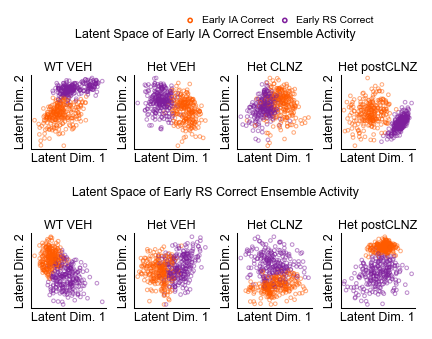

In [ ]:
plot_df = latent_embed_sample.rename({'geno_day': 'geno'},axis = 1)
comparison = 'Early_IA_Correct_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## make figure
latent_space_figsize = (2.75,2)
latent_space_gridspec = dict(wspace = 0.1, hspace = 0.2)
fig,ax_array = plt.subplots(nrows=len(ensemble_subset),ncols = len(geno_order), figsize = latent_space_figsize,
                            layout = 'constrained', gridspec_kw = latent_space_gridspec)
plot_class_scatter_in_latent(fig, ax_array, df_comparison, compared_col, ens_col, ensemble_subset, comparison, make_legend = True)
# ##save fig
fig_name = f"Autoencoder projection- latent space- {comparison} ens"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
# 6, filetypes_to_save = ['png','svg'])

Saved 6_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_01_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 6_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_01_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/6_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_01_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/6_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_01_Jan_2026.txt


[None, None]

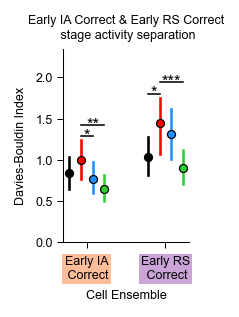

In [ ]:
##subfig 2: DB index
comparison = 'Early_IA_Correct_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
db_index_fig_size = (1.25,2.)
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,ylim = [0, 2.35],scale = 1.0, dodge = 0.45)
##save fig
fig_name = f"Autoencoder {comparison} DB index by ensembles"
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="6",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
# 6, filetypes_to_save = ['png','svg'])

#### latent space- IA v RS Error

[None, None]

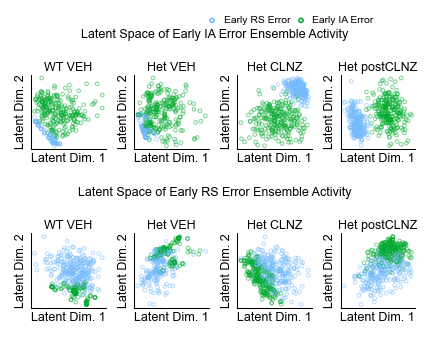

In [ ]:
## get df of interest
comparison = 'Early_IA_Error_v_Early_RS_Error'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## make figure
fig,ax_array = plt.subplots(nrows=len(ensemble_subset),ncols = len(geno_order), figsize = latent_space_figsize,
                            layout = 'constrained', gridspec_kw = latent_space_gridspec)
plot_class_scatter_in_latent(fig, ax_array, df_comparison, compared_col, ens_col, ensemble_subset, comparison, make_legend = True)
##save fig
fig_name = f"Autoencoder projection- latent space- {comparison} ens"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]


In [ ]:
fig_output

'g:\\My Drive\\Colab Notebooks\\lightning_autoencoder/output//figures/01_Jan_2026\\'

Saved 5_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc cohen d_01_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 5_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc cohen d_01_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/5_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc_results_text_01_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/5_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc_results_text_01_Jan_2026.txt


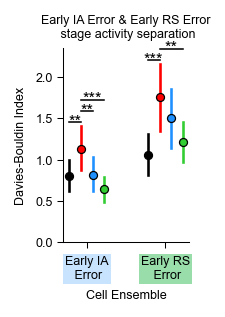

In [ ]:
comparison = 'Early_IA_Error_v_Early_RS_Error'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()

fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize =db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,ylim = [0, 2.35],scale = 1.0)
##save fig
fig_name = f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="5",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")

#### latent space- Late IA v RS Correct

[None, None]

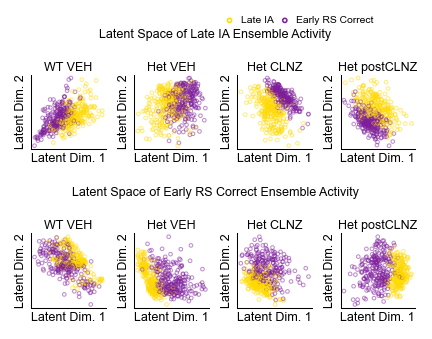

In [ ]:
## get df of interest
# plot_df = latent_embed_sample
comparison = 'Late_IA_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## make figure
fig,ax_array = plt.subplots(nrows=len(ensemble_subset),ncols = len(geno_order), figsize = latent_space_figsize,
                            layout = 'constrained', gridspec_kw = latent_space_gridspec)
plot_class_scatter_in_latent(fig, ax_array, df_comparison, compared_col, ens_col, ensemble_subset, comparison, make_legend = True) ##save fig
##save fig
fig_name = f"Autoencoder projection- latent space- {comparison} ens"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]


Saved 7_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 7_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/7_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/7_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


<Figure size 960x720 with 0 Axes>

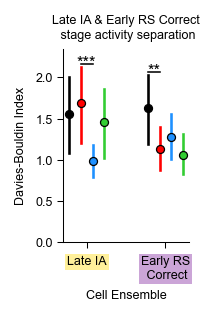

In [ ]:
## get df of interest
# plot_df = latent_embed_sample
comparison = 'Late_IA_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df ,ylim = [0, 2.35],scale = 1.0)
##save fig
fig_name = f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="7",fig_name,csv_folder_most_recent, csv_folder_current_run,csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")

[None, None]

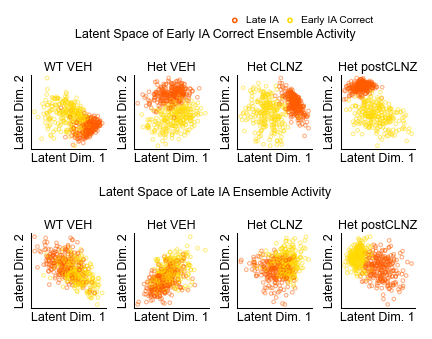

In [ ]:
## get df of interest
# plot_df = latent_embed_sample
comparison = 'Early_IA_Correct_v_Late_IA'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## make figure
fig,ax_array = plt.subplots(nrows=len(ensemble_subset),ncols = len(geno_order), figsize = latent_space_figsize,
                            layout = 'constrained', gridspec_kw = latent_space_gridspec)
plot_class_scatter_in_latent(fig, ax_array, df_comparison, compared_col, ens_col, ensemble_subset, comparison, make_legend = True)
##save fig
fig_name = f"Autoencoder projection- latent space- {comparison} ens"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]


Saved 7_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 7_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/7_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/7_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


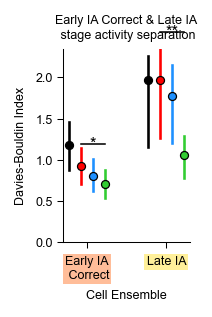

In [ ]:
# plot_df = latent_embed_sample
comparison = 'Early_IA_Correct_v_Late_IA'## get df of interest
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## function for plotting DB index for ensemble subset##
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,ylim = [0, 2.35],scale = 1.0)
##save fig
fig_name = f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="7",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
   

## Supplement DB index plots

#### Latent space-IA v RS Correct 

In [ ]:
latent_embed_sample = embed_record

##set latent space shared variables
compared_col = 'classes_decoded'
ens_col = 'ensemble'

In [ ]:
supp_figure_prefix = "supp_"

switching posthoc comparison to include WT CLNZ
Saved 6_s_supp_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 6_s_supp_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/6_s_supp_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/6_s_supp_Autoencoder Early_IA_Correct_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


[None, None]

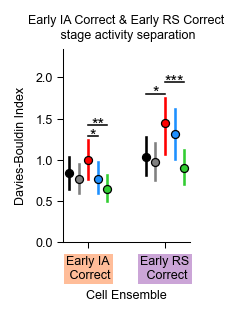

In [ ]:
##subfig 2: DB index
comparison = 'Early_IA_Correct_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
db_index_fig_size = (1.25,2.)
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df, geno_plot = geno_order_w_WT_CLNZ, ylim = [0, 2.35],scale = 1.0,dodge = 0.5)
##save fig
fig_name = supp_figure_prefix+ f"Autoencoder {comparison} DB index by ensembles"
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="6_s",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
# 6, filetypes_to_save = ['png','svg'])

#### latent space- IA v RS Error

In [ ]:
comparison_list_w_WT_CLNZ

[('WT VEH', 'WT CLNZ'),
 ('WT VEH', 'Het VEH'),
 ('Het VEH', 'Het CLNZ'),
 ('Het VEH', 'Het postCLNZ')]

In [ ]:
preset_comparison_list

[('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ'), ('Het VEH', 'Het postCLNZ')]

switching posthoc comparison to include WT CLNZ


C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()
C:\Users\13car\AppData\Local\Temp\ipykernel_100312\1945255548.py:12: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  [fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]


Saved 5_s_supp_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 5_s_supp_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/5_s_supp_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/5_s_supp_Autoencoder Early_IA_Error_v_Early_RS_Error DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


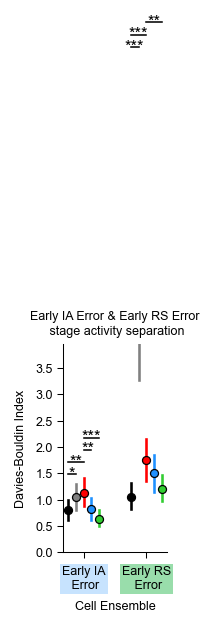

In [ ]:
comparison = 'Early_IA_Error_v_Early_RS_Error'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()

fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize =db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,geno_plot = geno_order_w_WT_CLNZ,
                                     ylim = [0, 3.95],scale = 1.0,dodge = 0.5)
##save fig
fig_name =supp_figure_prefix+  f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="5_s",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")

#### latent space- Late IA v RS Correct

switching posthoc comparison to include WT CLNZ
Saved 7_s_supp_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 7_s_supp_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/7_s_supp_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/7_s_supp_Autoencoder Late_IA_v_Early_RS_Correct DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


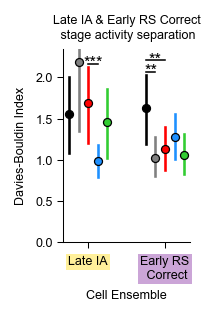

In [ ]:
## get df of interest
# plot_df = latent_embed_sample
comparison = 'Late_IA_v_Early_RS_Correct'
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
## function for plotting DB index for ensemble subset
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,geno_plot = geno_order_w_WT_CLNZ,
                                     ylim = [0, 2.35],scale = 1.0,dodge = 0.5)
##save fig
fig_name =supp_figure_prefix+  f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="7_s",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")

switching posthoc comparison to include WT CLNZ
Saved 7_s_supp_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved 7_s_supp_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc cohen d_02_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_01_Jan_2026/7_s_supp_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc_results_text_02_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/7_s_supp_Autoencoder Early_IA_Correct_v_Late_IA DB index by ensembles_posthoc_results_text_02_Jan_2026.txt


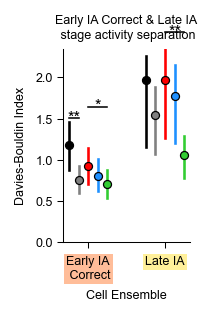

In [ ]:
# plot_df = latent_embed_sample
comparison = 'Early_IA_Correct_v_Late_IA'## get df of interest
df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
ensemble_subset = df_comparison[ens_col].unique()
## function for plotting DB index for ensemble subset##
fig, plot_ax = plt.subplots(nrows=1,ncols =1,figsize = db_index_fig_size,layout = 'constrained')
posthoc_df= plot_db_index_geno_dodge(plot_ax, comparison, ensemble_subset, score_df,
                                     geno_plot = geno_order_w_WT_CLNZ,
                                     ylim = [0, 2.35],scale = 1.0,dodge = 0.5)
##save fig
fig_name =supp_figure_prefix+  f"Autoencoder {comparison} DB index by ensembles"
# save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
[fig.savefig(fig_output + fig_name + f".{fig_type}", **{ 'dpi': 300,'pad_inches':0.025}) for fig_type in ['png', 'svg']]

#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="7_s",fig_name,csv_folder_most_recent, csv_folder_current_run, csv_suffix="posthoc cohen d",txt_suffix="posthoc_results_text")
   

In [ ]:
os.getcwd()

'g:\\My Drive\\Colab Notebooks\\lightning_autoencoder'

## Master Figure: All DB Index Comparisons

Combine all `plot_db_index_geno_dodge` plots into a single multi-panel figure.

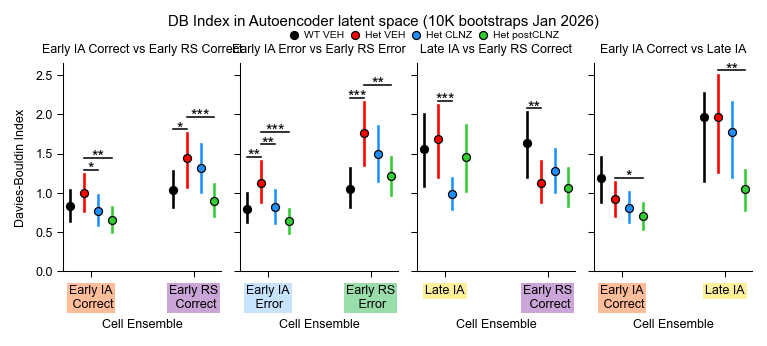

In [55]:
# Define all comparisons to include in master figure
# Main figure comparisons (4 genotypes)
main_comparisons = [
    'Early_IA_Correct_v_Early_RS_Correct',
    'Early_IA_Error_v_Early_RS_Error',
    'Late_IA_v_Early_RS_Correct',
    'Early_IA_Correct_v_Late_IA',
]

# Create master figure with subfigures
n_comparisons = len(main_comparisons)
fig, axes = plt.subplots(nrows=1, ncols=n_comparisons, 
                         figsize=(n_comparisons * 1.25, 2), layout='constrained', sharey=True)
# Store all posthoc results
all_posthoc = []
# Plot each comparison in a subfigure
for ax, comparison in zip(axes, main_comparisons):
    df_comparison = plot_df.loc[(plot_df[compared_col] == comparison), :]
    ensemble_subset = df_comparison[ens_col].unique()
    
    posthoc_df = plot_db_index_geno_dodge(
        ax, comparison, ensemble_subset, score_df,
        ylim=[0, 2.65], scale=1.0, dodge=0.4,
        add_legend=(ax == axes[-1])  # Legend only on last subplot
    )
    all_posthoc.append(posthoc_df)
    
    # Clean up title for subfigure
    title = comparison.replace('_v_', ' vs ').replace('_', ' ')
    ax.set_title(title, )
    # Only show y-label on first subplot
    if ax != axes[0]:
        ax.set_ylabel('')

fig.suptitle('DB Index in Autoencoder latent space (10K bootstraps Jan 2026)',y=1.075)
# Save master figure
fig_name = "Master_Figure_All_DB_Index_Comparisons_main_genos"
# [fig.savefig(fig_output + fig_name + f".{fig_type}", dpi=300, bbox_inches='tight') 
#  for fig_type in ['png', 'svg', 'pdf']]
# print(f"Saved: {fig_name}")

switching posthoc comparison to include WT CLNZ
switching posthoc comparison to include WT CLNZ


C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()


switching posthoc comparison to include WT CLNZ


C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()
C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()


switching posthoc comparison to include WT CLNZ


C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()
C:\Users\13car\Dropbox\local_github_repos_personal\plot_posthoc_test\src\plot_posthoc_test\plot_stat_annotate.py:217: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  ax_input.figure.canvas.draw()
C:\Users\13car\AppData\Local\Temp\ipykernel_65036\1942267494.py:38: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  [fig_supp.savefig(fig_output + fig_name_supp + f".{fig_type}", dpi=300, bbox_inches='tight')
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout no

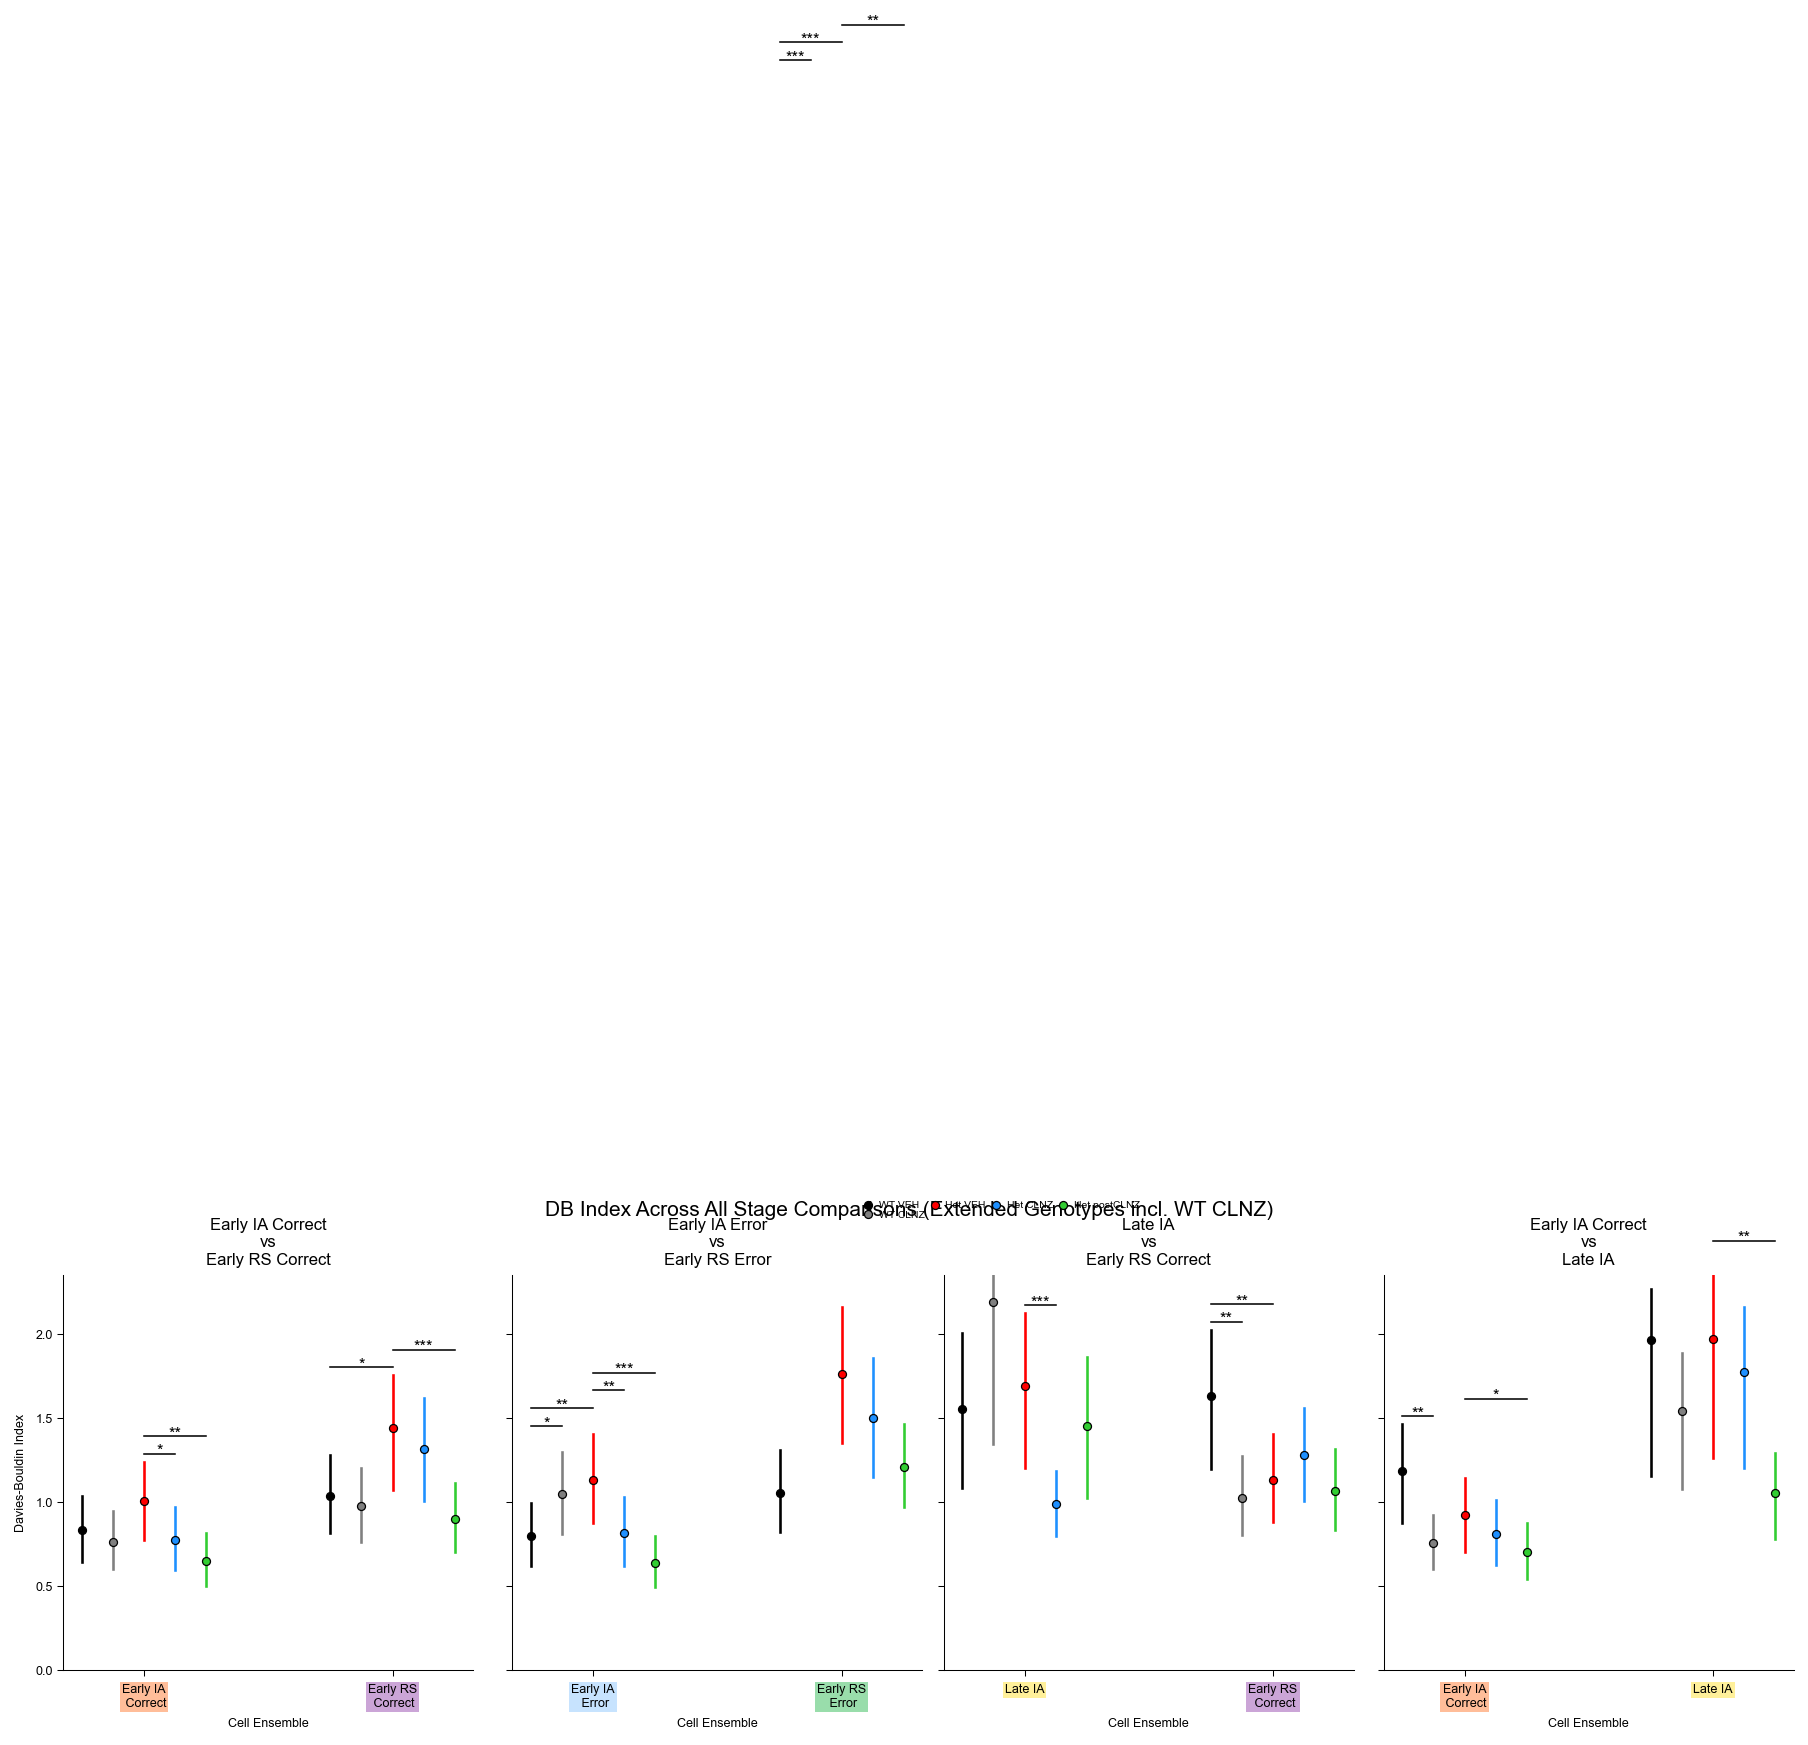

Saved: supp_Master_Figure_All_DB_Index_Comparisons_extended_genos


In [49]:
# Supplementary figure with extended genotypes (including WT CLNZ)
supp_comparisons = [
    'Early_IA_Correct_v_Early_RS_Correct',
    'Early_IA_Error_v_Early_RS_Error',
    'Late_IA_v_Early_RS_Correct',
    'Early_IA_Correct_v_Late_IA',
]

n_comparisons = len(supp_comparisons)
fig_supp, axes_supp = plt.subplots(nrows=1, ncols=n_comparisons, 
                                    figsize=(n_comparisons * 3, 3.5), 
                                    layout='constrained', sharey=True)

all_posthoc_supp = []

for ax, comparison in zip(axes_supp, supp_comparisons):
    df_comparison = plot_df.loc[(plot_df[compared_col] == comparison), :]
    ensemble_subset = df_comparison[ens_col].unique()
    
    posthoc_df = plot_db_index_geno_dodge(
        ax, comparison, ensemble_subset, score_df,
        geno_plot=geno_order_w_WT_CLNZ,  # Extended genotype list
        ylim=[0, 2.35], scale=1.0, dodge=0.5,
        add_legend=(ax == axes_supp[-1])
    )
    all_posthoc_supp.append(posthoc_df)
    
    title = comparison.replace('_v_', '\nvs\n').replace('_', ' ')
    ax.set_title(title, fontsize=8)
    
    if ax != axes_supp[0]:
        ax.set_ylabel('')

fig_supp.suptitle('DB Index Across All Stage Comparisons (Extended Genotypes incl. WT CLNZ)', 
                  fontsize=10, y=1.02)

fig_name_supp = supp_figure_prefix + "Master_Figure_All_DB_Index_Comparisons_extended_genos"
[fig_supp.savefig(fig_output + fig_name_supp + f".{fig_type}", dpi=300, bbox_inches='tight') 
 for fig_type in ['png', 'svg', 'pdf']]

plt.show()
print(f"Saved: {fig_name_supp}")

In [50]:
# Combine and save all posthoc results from master figures
combined_posthoc_main = pd.concat(all_posthoc, ignore_index=True)
combined_posthoc_supp = pd.concat(all_posthoc_supp, ignore_index=True)

# Save combined posthoc tables
save_plot_record_as_csv_txt(
    combined_posthoc_main,
    folder_pref="Master_Main",
    fig_name="All_DB_Index_Comparisons_main_genos",
    csv_folder_most_recent=csv_folder_most_recent,
    csv_folder_current_run=csv_folder_current_run,
    csv_suffix="posthoc_cohen_d",
    txt_suffix="posthoc_results_text"
)

save_plot_record_as_csv_txt(
    combined_posthoc_supp,
    folder_pref="Master_Supp",
    fig_name="All_DB_Index_Comparisons_extended_genos",
    csv_folder_most_recent=csv_folder_most_recent,
    csv_folder_current_run=csv_folder_current_run,
    csv_suffix="posthoc_cohen_d",
    txt_suffix="posthoc_results_text"
)

print(f"Main figure posthoc: {len(combined_posthoc_main)} comparisons")
print(f"Supp figure posthoc: {len(combined_posthoc_supp)} comparisons")

Saved Master_Main_All_DB_Index_Comparisons_main_genos_posthoc_cohen_d_16_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved Master_Main_All_DB_Index_Comparisons_main_genos_posthoc_cohen_d_16_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_16_Jan_2026/
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/analysis_CSV_storage_16_Jan_2026/Master_Main_All_DB_Index_Comparisons_main_genos_posthoc_results_text_16_Jan_2026.txt
Output saved to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/Master_Main_All_DB_Index_Comparisons_main_genos_posthoc_results_text_16_Jan_2026.txt
Saved Master_Supp_All_DB_Index_Comparisons_extended_genos_posthoc_cohen_d_16_Jan_2026.csv to g:\My Drive\Colab Notebooks\lightning_autoencoder/output/most_recent_analysis_CSV_storage/
Saved Master_Supp_All_DB_Index_Comparisons_extended_genos_posthoc_cohen_d_